# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

## Setup and load data
Add the project root to the import path, load the TXT dataset, and split into train/test for modeling.

In [ ]:
from pathlib import Path
import sys
import pandas as pd

# Ensure project root is on sys.path for imports
project_root = Path("../..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_txt, preprocess, GWASDataset

illnesses = [["MDD", "0.001"], ["ADHD", "0.001"], ["ASD", "0.001"], ["OCD", "0.001"], ["SCZ", "0.0001"], ["BIP", "0.001"]]

illness_to_ID = {
    "MDD": 0,
    "ADHD": 1,
    "ASD": 2,
    "OCD": 3,
    "SCZ": 4,
    "BIP": 5
}

df_illnesses = {}

for illness, clumping in illnesses:
    data_path = Path(f"../../data/tmpDATA-Leon/donnees_MRI_{illness}_only_variants_clumping_p_thr_{clumping}all.txt")
    df_illnesses[illness] = load_txt(data_path)

    #rename Z_scores columns to just Z_scores 
    df_illnesses[illness] = df_illnesses[illness].rename(columns={col: "Z_scores" for col in df_illnesses[illness].columns if col.startswith("Z_scores")})
    
# add column illness with illness ID to each row of each dataframe
for illness, df in df_illnesses.items():
    df["illness"] =  illness_to_ID[illness]

# combine all dataframes into one
df = pd.concat(df_illnesses.values(), ignore_index=True)

df.info()


#X_train, y_train, X_test, y_test = preprocess(df=df_mdd, target=f"Z_scores_{type}", testsize = 0.2)


<class 'pandas.DataFrame'>
RangeIndex: 20428 entries, 0 to 20427
Columns: 1013 entries, Mean_intensity_3rd-Ventricle_whole-brain to illness
dtypes: float64(1011), int64(1), str(1)
memory usage: 157.9 MB


/var/folders/tb/n2h9svys065dbxwsjcty_7j00000gn/T/ipykernel_45427/3125377489.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["illness"] =  illness_to_ID[illness]


In [28]:
df.head()

,Mean_intensity_3rd-Ventricle_whole-brain,Mean_intensity_4th-Ventricle_whole-brain,Mean_intensity_Brain-Stem_whole-brain,Mean_intensity_CSF_whole-brain,Mean_intensity_WM-hypointensities_whole-brain,Mean_intensity_Optic-Chiasm_whole-brain,Mean_intensity_CC-Posterior_whole-brain,Mean_intensity_CC-Mid-Posterior_whole-brain,Mean_intensity_CC-Central_whole-brain,Mean_intensity_CC-Mid-Anterior_whole-brain,...,Volume_S-precentral-inf-part_right,Volume_S-precentral-sup-part_right,Volume_S-suborbital_right,Volume_S-subparietal_right,Volume_S-temporal-inf_right,Volume_S-temporal-sup_right,Volume_S-temporal-transverse_right,Z_scores,ID,illness
0,-0.909895,-0.335305,0.519297,-0.555432,0.756546,-0.477407,1.212950,0.529090,1.019100,1.192580,...,-0.118828,-1.353370,1.423650,-0.934246,-0.106361,-0.201944,0.219648,-3.390360,rs10903385,0
1,-0.678412,1.166110,-0.162587,-1.929640,0.855909,-0.143850,-1.085770,0.610258,1.297300,0.702451,...,-1.024000,0.280131,2.874470,0.694286,0.309240,-0.533916,1.673910,-3.311167,rs1392828,0
2,1.116720,0.719322,2.042310,1.862870,-1.313900,-0.488740,0.178764,0.298260,0.458461,-0.058223,...,0.157822,-0.976112,-1.539300,0.775611,-0.931109,-0.822349,-0.844325,3.633392,rs145358842,0
3,-0.039337,1.658240,0.327507,0.895273,1.092190,0.191609,0.310098,1.277860,0.387303,-1.085630,...,0.557382,1.783520,-0.308143,-1.684860,-0.497441,-0.534644,1.414330,-3.835441,rs188848422,0
4,0.494151,1.168270,0.949132,0.897002,2.057640,0.762612,0.490406,-0.150986,1.059360,-1.107590,...,1.862120,1.522980,0.876647,-0.073244,-0.276852,0.094010,1.677220,-3.432097,rs10903459,0


In [ ]:
# count number of samples 


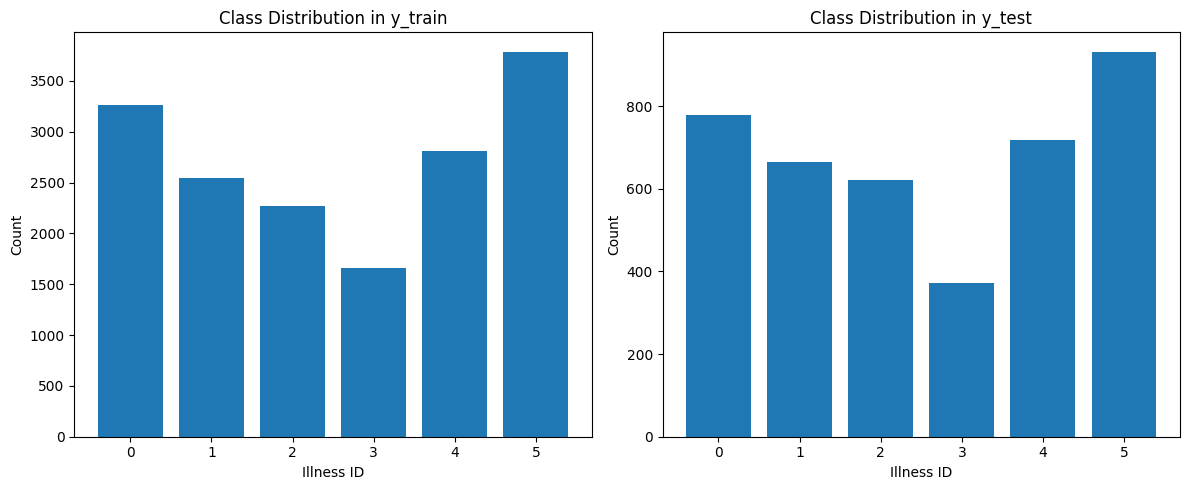

In [26]:
X_train, y_train, X_test, y_test = preprocess(df=df, target=f"illness", testsize = 0.2)
# plot class distribution in y_train and y_test
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=range(7), align='left', rwidth=0.8)
plt.title("Class Distribution in y_train")
plt.xlabel("Illness ID")
plt.ylabel("Count")
plt.subplot(1, 2, 2)
plt.hist(y_test, bins=range(7), align='left', rwidth=0.8)
plt.title("Class Distribution in y_test")
plt.xlabel("Illness ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()  

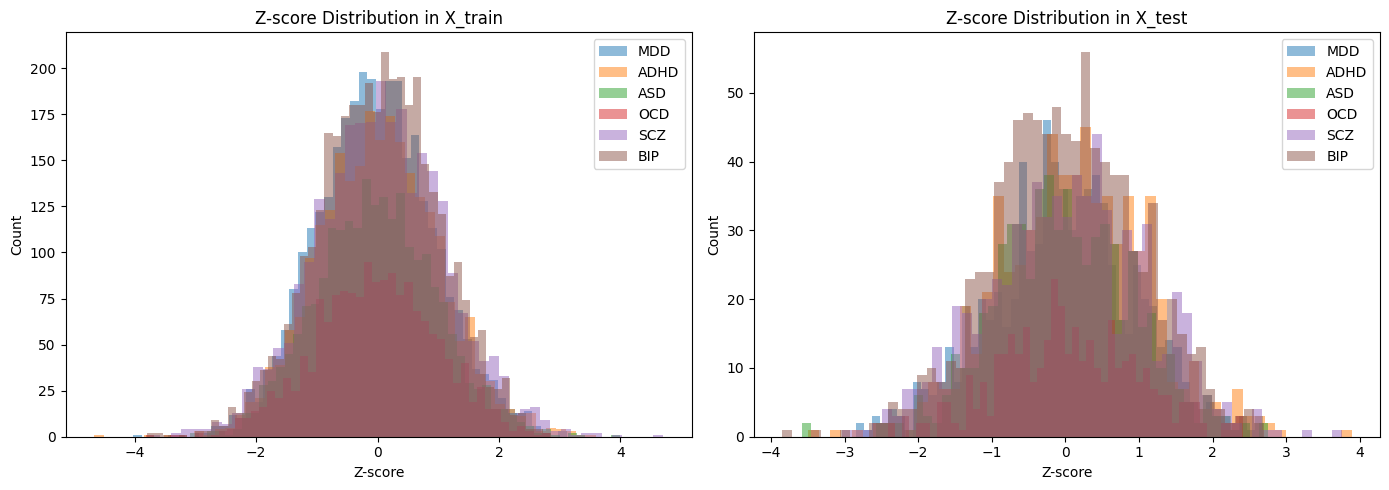

In [ ]:
# plot z score distribution per illness for train and test
ID_to_illness = {v: k for k, v in illness_to_ID.items()}
n_illnesses = len(illness_to_ID)

fig, axes = plt.subplots(n_illnesses, 2, figsize=(14, 3 * n_illnesses), sharex=True)

for i, illness_id in enumerate(sorted(illness_to_ID.values())):
    label = ID_to_illness[illness_id]
    mask_train = y_train == illness_id
    mask_test = y_test == illness_id

    axes[i, 0].hist(X_train[mask_train, 0], bins=50, color=f"C{i}")
    axes[i, 0].set_ylabel(label)
    if i == 0:
        axes[i, 0].set_title("Z-score Distribution in X_train")

    axes[i, 1].hist(X_test[mask_test, 0], bins=50, color=f"C{i}")
    if i == 0:
        axes[i, 1].set_title("Z-score Distribution in X_test")

axes[-1, 0].set_xlabel("Z-score")
axes[-1, 1].set_xlabel("Z-score")

plt.tight_layout()
plt.show()

## Build PyTorch data loaders
Create datasets and loaders using the top 100 features.

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(GWASDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(GWASDataset(X_test, y_test), batch_size=32, shuffle=False)

## Define the DNN model
Instantiate a small neural network for regression.

In [20]:
from model import DNN

model = DNN(input_dim=X_train.shape[1], hidden_dims=[100, 100], output_dim=6, dropout=0.2)
print(model)

DNN(
  (network): Sequential(
    (0): Linear(in_features=1010, out_features=100, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=100, out_features=6, bias=True)
  )
)


## Train the DNN
Optimize the model and track train/test loss per epoch.

In [21]:
from torch import nn, optim
import torch

#criterion = nn.MSELoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
test_losses = []
 
for epoch in range(50):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y.view(-1).long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_X.size(0)
    train_losses.append(total_loss / len(train_loader.dataset))
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

    model.eval()
 
    with torch.no_grad():
        test_loss = 0
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y.view(-1).long())
            test_loss += loss.item() * batch_X.size(0)
    
    average_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(average_test_loss)
    print(f"Test Loss: {average_test_loss:.4f}")

Epoch 1, Loss: 1.7532
Test Loss: 1.7334
Epoch 2, Loss: 1.7264
Test Loss: 1.7262
Epoch 3, Loss: 1.7077
Test Loss: 1.7164
Epoch 4, Loss: 1.6887
Test Loss: 1.7116
Epoch 5, Loss: 1.6711
Test Loss: 1.7043
Epoch 6, Loss: 1.6477
Test Loss: 1.7021
Epoch 7, Loss: 1.6232
Test Loss: 1.7013
Epoch 8, Loss: 1.5975
Test Loss: 1.6982
Epoch 9, Loss: 1.5706
Test Loss: 1.7076
Epoch 10, Loss: 1.5483
Test Loss: 1.7016
Epoch 11, Loss: 1.5229
Test Loss: 1.7092
Epoch 12, Loss: 1.4981
Test Loss: 1.7128
Epoch 13, Loss: 1.4713
Test Loss: 1.7184
Epoch 14, Loss: 1.4483
Test Loss: 1.7276
Epoch 15, Loss: 1.4237
Test Loss: 1.7260
Epoch 16, Loss: 1.3917
Test Loss: 1.7368
Epoch 17, Loss: 1.3705
Test Loss: 1.7447
Epoch 18, Loss: 1.3483
Test Loss: 1.7514
Epoch 19, Loss: 1.3236
Test Loss: 1.7648
Epoch 20, Loss: 1.3055
Test Loss: 1.7656
Epoch 21, Loss: 1.2805
Test Loss: 1.7747
Epoch 22, Loss: 1.2644
Test Loss: 1.7827
Epoch 23, Loss: 1.2382
Test Loss: 1.7968
Epoch 24, Loss: 1.2172
Test Loss: 1.8029
Epoch 25, Loss: 1.2016
Te

## Plot training curves
Visualize train vs. test loss over epochs.

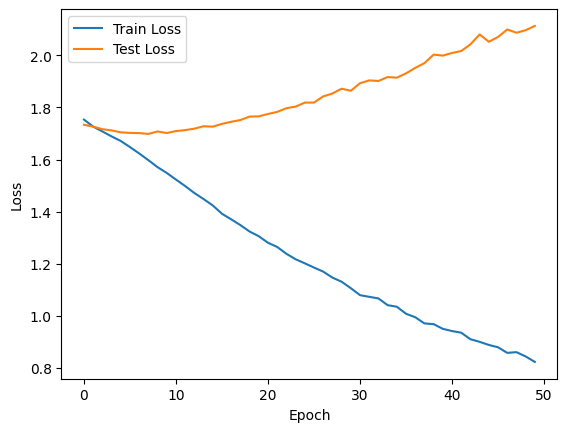

In [22]:
# plot training and test losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test, dtype=torch.float32))
    preds = torch.argmax(logits, dim=1).numpy()

y_true = y_test.values.astype(int)

print(f"Accuracy: {accuracy_score(y_true, preds):.4f}")
print()
print(classification_report(y_true, preds, target_names=list(illness_to_ID.keys())))


Accuracy: 0.3130

              precision    recall  f1-score   support

         MDD       0.28      0.31      0.29       778
        ADHD       0.29      0.28      0.29       665
         ASD       0.31      0.24      0.27       621
         OCD       0.16      0.14      0.15       371
         SCZ       0.44      0.42      0.43       719
         BIP       0.32      0.37      0.34       932

    accuracy                           0.31      4086
   macro avg       0.30      0.29      0.30      4086
weighted avg       0.31      0.31      0.31      4086

